In [2]:
from google.colab import files

uploaded = files.upload()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")

In [7]:
df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [8]:
df.shape

(360, 16)

In [9]:
df.columns

Index(['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine',
       'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue',
       'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes',
       'Customer_Rating', 'Repeat_Customer_Percent'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Customer_Rating          3

In [11]:
df.describe()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
std,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472
min,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000


In [12]:
df.isnull().sum()

,0
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


### Convert the Date column

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-nul

### Check for Missing Values and Duplicates

In [14]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64

Duplicate Rows:
0


### Orders Over Time — Line Plot

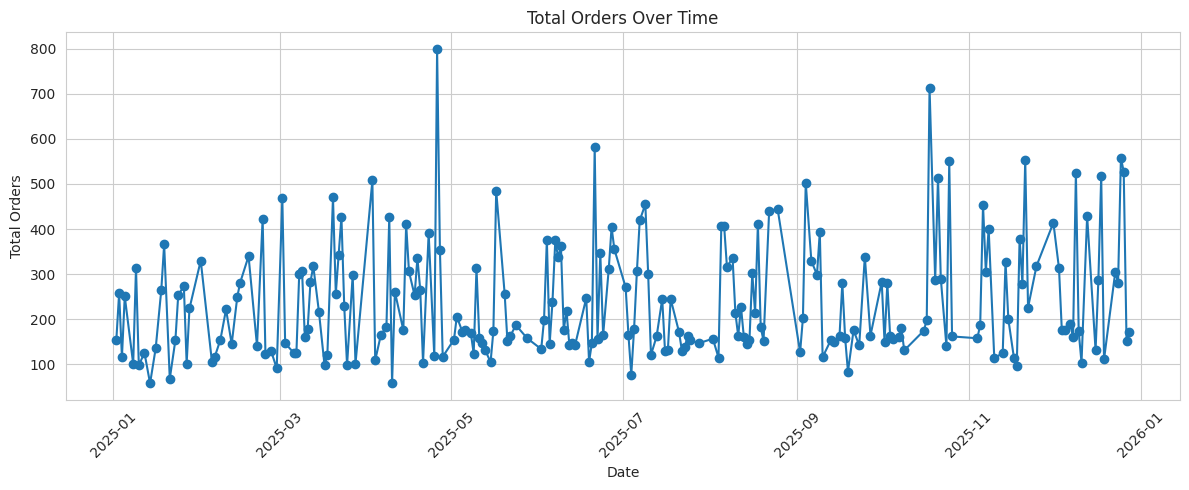

In [15]:
# Group orders by date
orders_over_time = df.groupby('Date')['Orders'].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    orders_over_time.index,
    orders_over_time.values,
    marker='o'
)

plt.title("Total Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Revenue Over Time — Line Plot

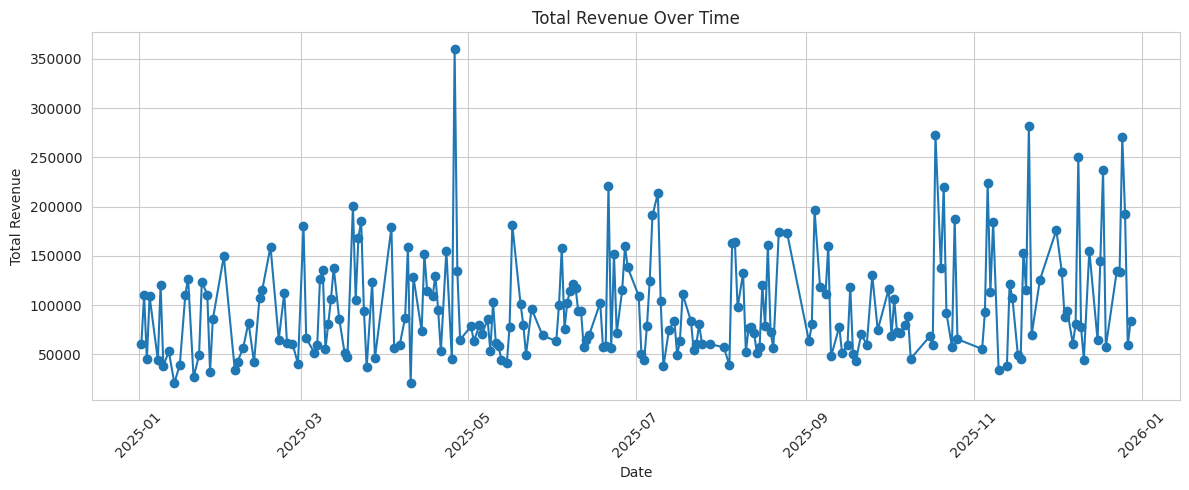

In [16]:
revenue_over_time = df.groupby('Date')['Revenue'].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    revenue_over_time.index,
    revenue_over_time.values,
    marker='o'
)

plt.title("Total Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Orders by City — Bar Chart

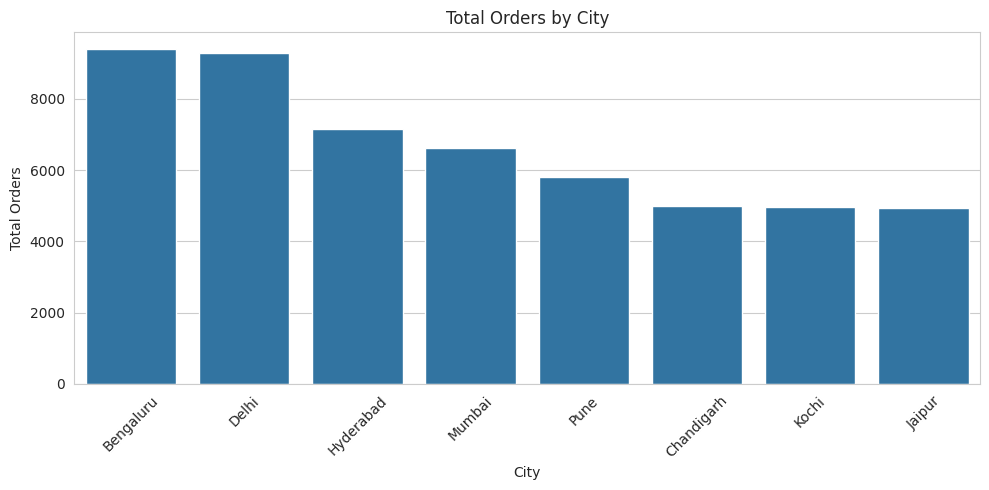

In [17]:
city_orders = df.groupby('City')['Orders'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=city_orders.index,
    y=city_orders.values
)

plt.title("Total Orders by City")
plt.xlabel("City")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Revenue by Cuisine — Bar Chart

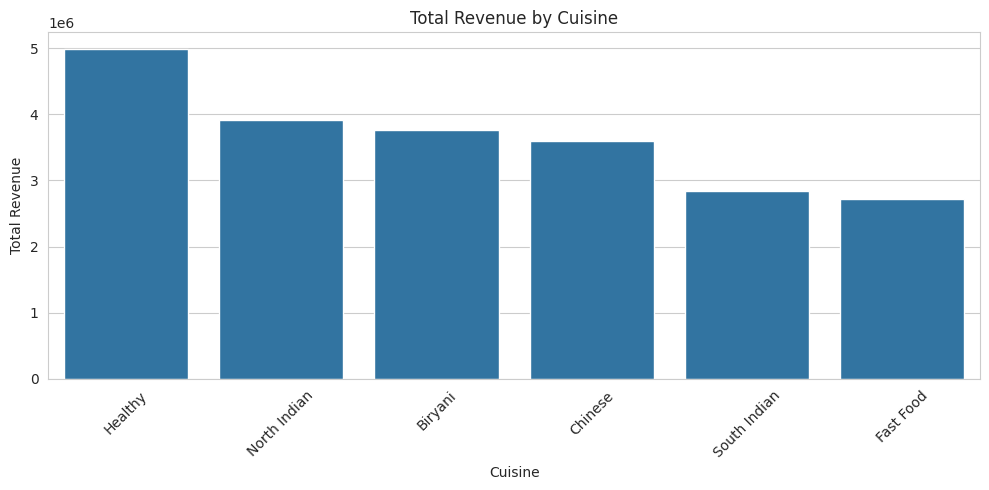

In [18]:
cuisine_revenue = df.groupby('Cuisine')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=cuisine_revenue.index,
    y=cuisine_revenue.values
)

plt.title("Total Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Interpretation

This visualization compares revenue generated by different cuisines. The cuisine generating the highest revenue may represent a particularly popular or profitable category for the food delivery business.

## Scatter Plots
Marketing Spend vs Revenue

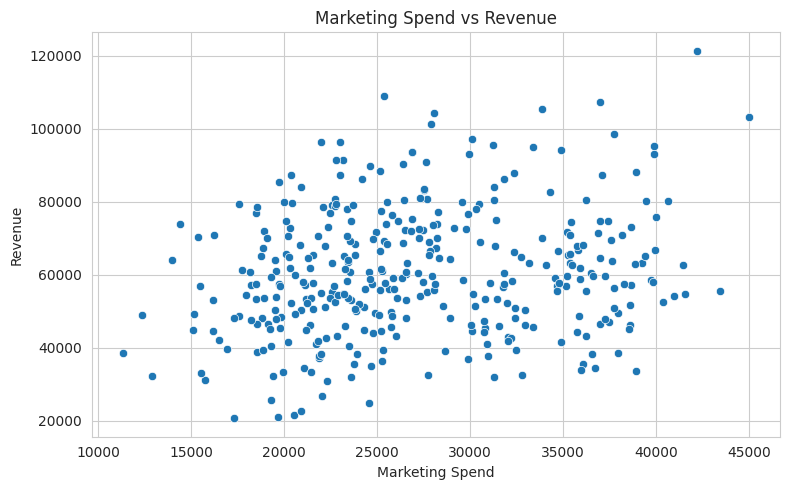

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Revenue'
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Delivery Time vs Customer Rating

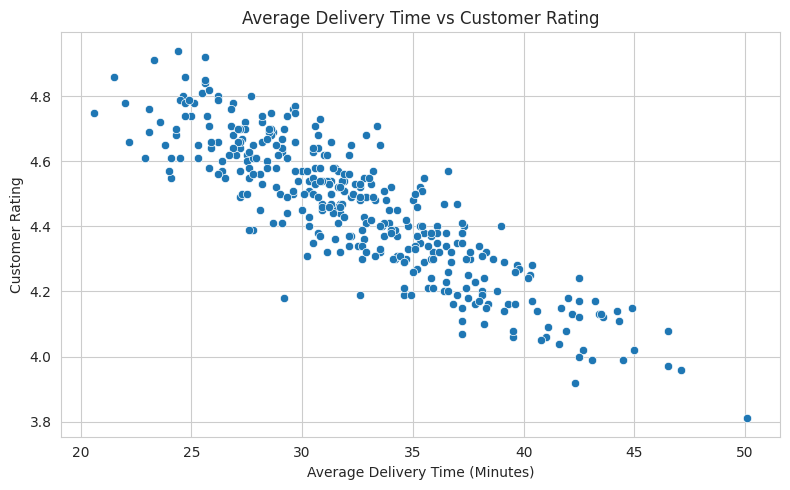

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating'
)

plt.title("Average Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.tight_layout()
plt.show()

## Histogram
Distribution of Orders

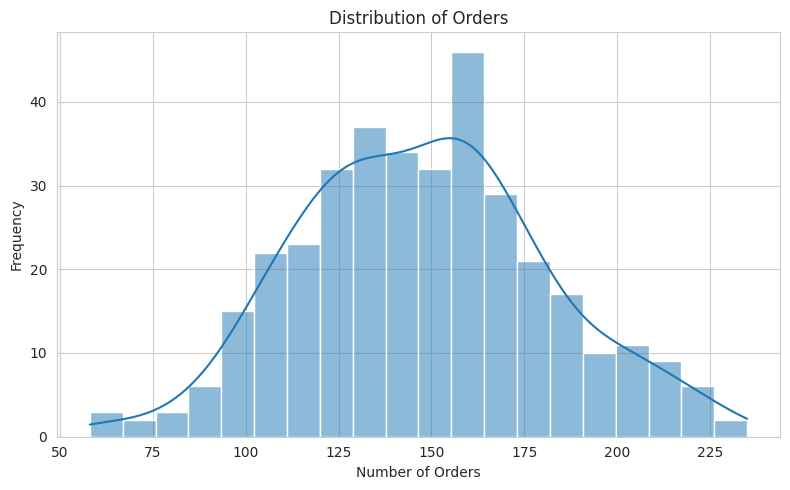

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Orders',
    bins=20,
    kde=True
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Box Plot

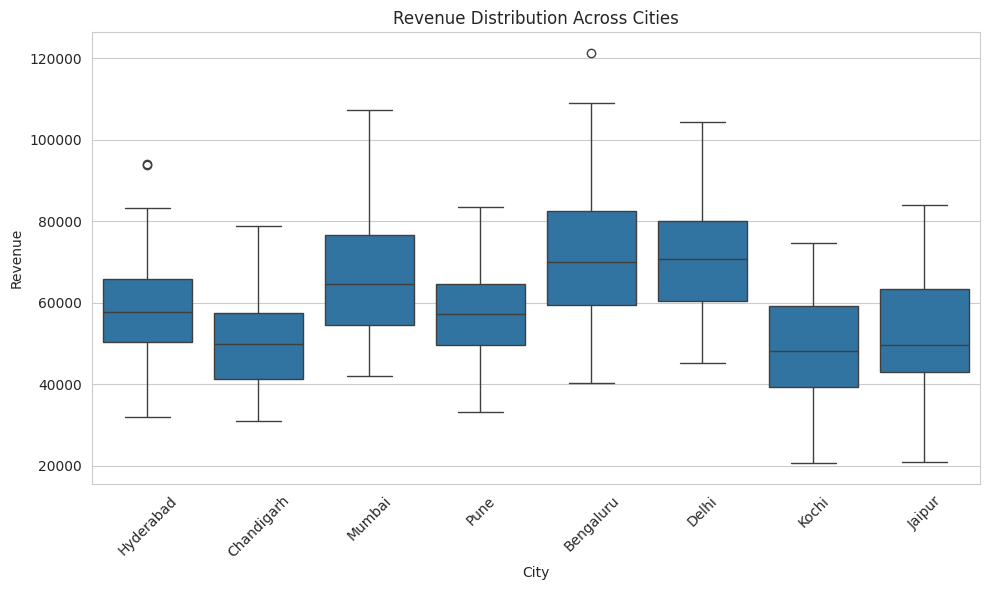

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='City',
    y='Revenue'
)

plt.title("Revenue Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Violin Plot

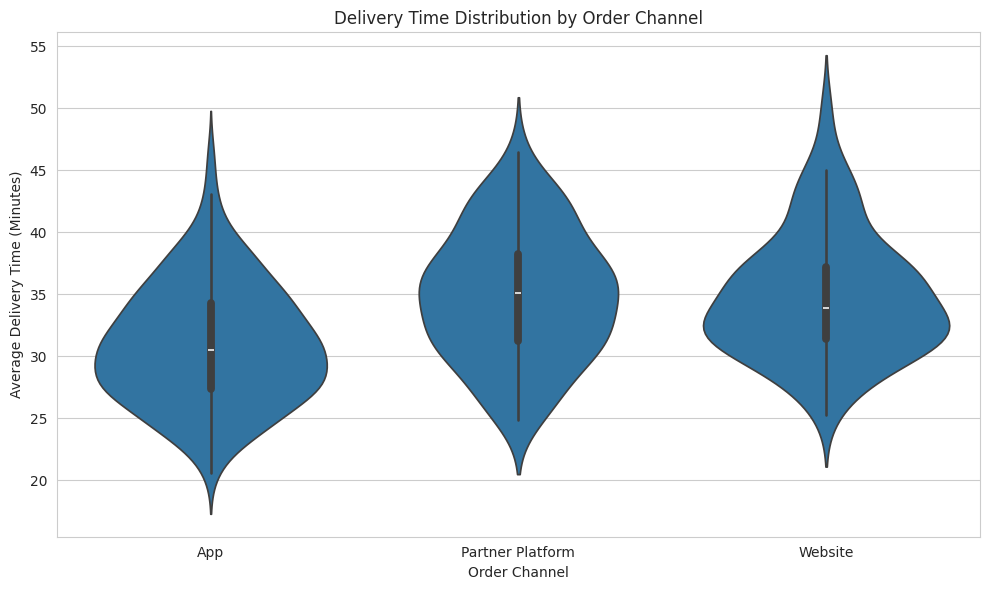

In [23]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Order_Channel',
    y='Avg_Delivery_Minutes'
)

plt.title("Delivery Time Distribution by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Delivery Time (Minutes)")

plt.tight_layout()
plt.show()

### Count Plot

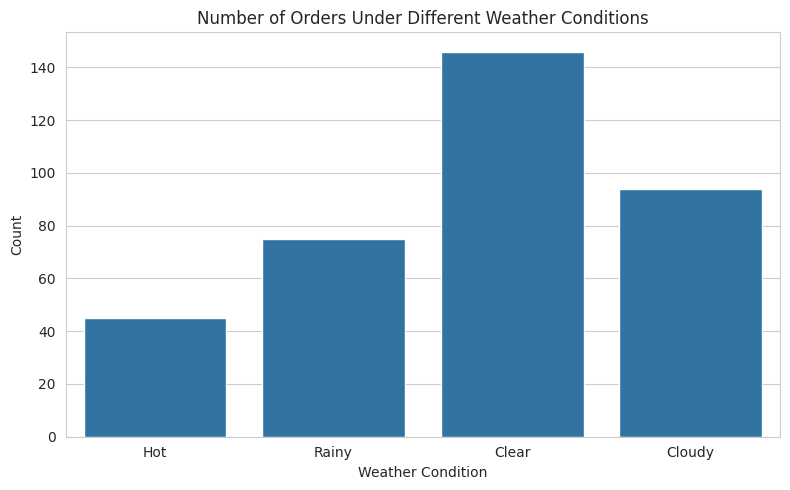

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Weather'
)

plt.title("Number of Orders Under Different Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Another Count Plot: Order Channels

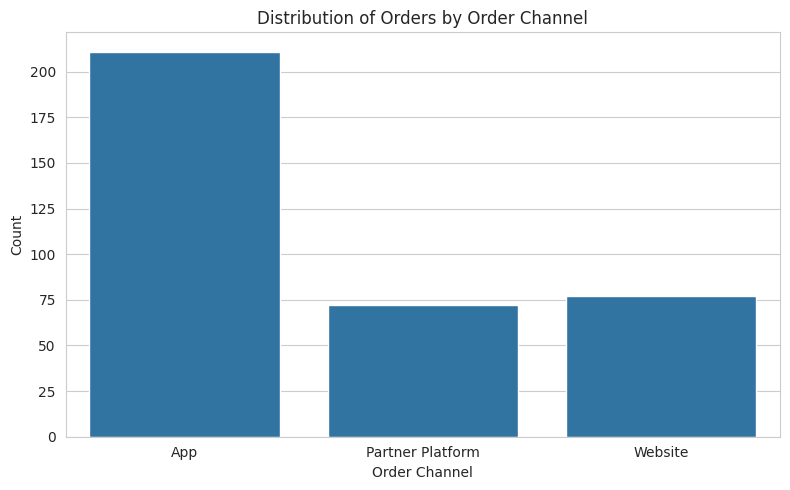

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Order_Channel'
)

plt.title("Distribution of Orders by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Correlation Heatmap

In [26]:
numeric_df = df.select_dtypes(include='number')

numeric_df.head()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


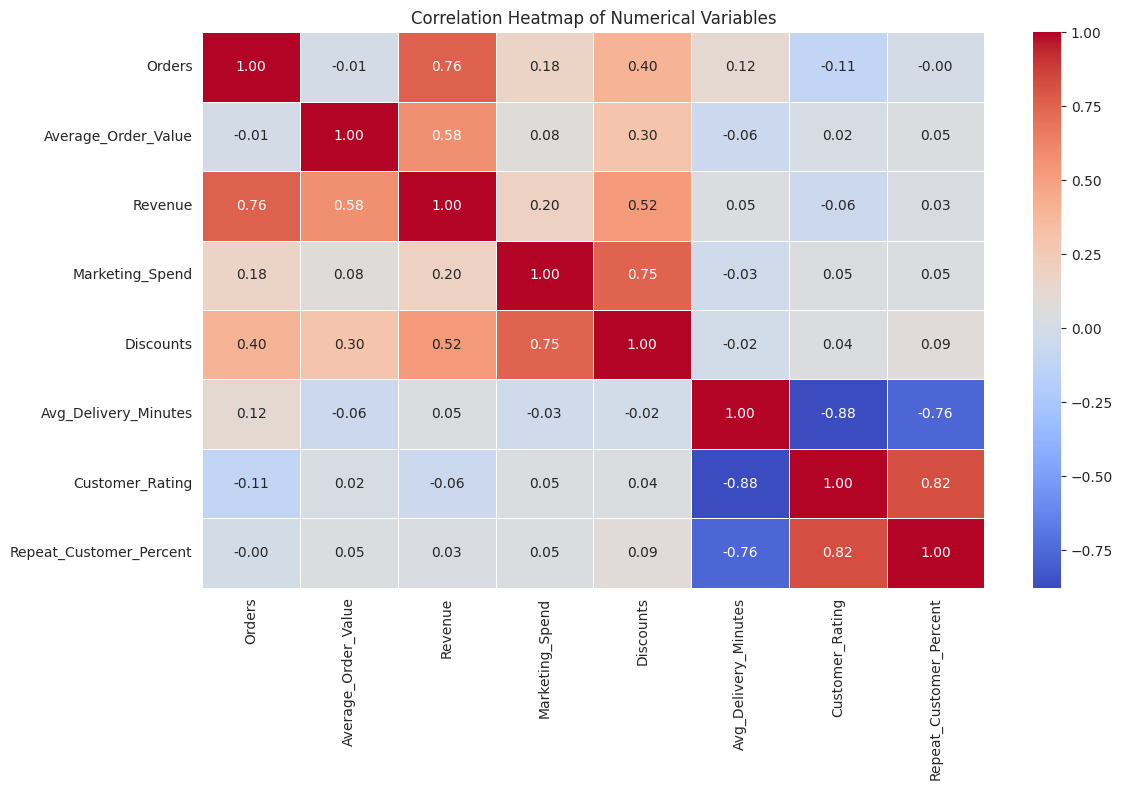

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

## Interpretation

The correlation heatmap shows the relationships between numerical variables in the dataset. Values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or no linear relationship.